This notebook provides a brief demonstration and explanation of the proposed methods. It shows:
- how we implement the simulation of quantum states and the measurement; 
- how we perform density matrix reconstruction using the maximum likelihood estimator (MLE); 
- how we implement a variational autoencoder (VAE) to adapt and reconstruct the probability distribution of the measurement outcomes.

# Import

In [3]:
# general import: 
import sys
import time
import os
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# quantum-lib import:
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city, plot_state_hinton, plot_state_qsphere

In [5]:
# machine-learning import:
import tensorflow as tf
import keras
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import sklearn
from sklearn.model_selection import train_test_split

In [6]:
# custom helper and libraries:
sys.path.append('../src')
from povm_sampling import *     # provides all the necessary to generate povm measurment samples
from statesprep import *        # contains the shortcut to construct the quantum circuits/states
from vae import *               # provides all the necessary to implement VAE
from mle import *               # provides all the necessary to implement MLE
from plots import *             # shortcuts to plot some infos
from utils import *             # general helpers or recurrent functions


# GHZ 3-qubit system

Let's consider the GHZ state for a 3 qubits system:

$\ket{\psi}= \frac{1}{\sqrt{2}}(\ket{000} + \ket{111} )$

## Data Generation via POVM Sampling

In this section, we generate the synthetic datasets by sampling possible outcomes directly from the exact theoretical probability distribution associated with the true quantum state.

quantum circuit of the GHZ3 state:


┌───┐          
q_0: ┤ H ├──■────■──
     └───┘┌─┴─┐  │  
q_1: ─────┤ X ├──┼──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘

Density matrix of GHZ3 state:

[[0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]]

Nice plots to draw the density matrix provided by qiskit:


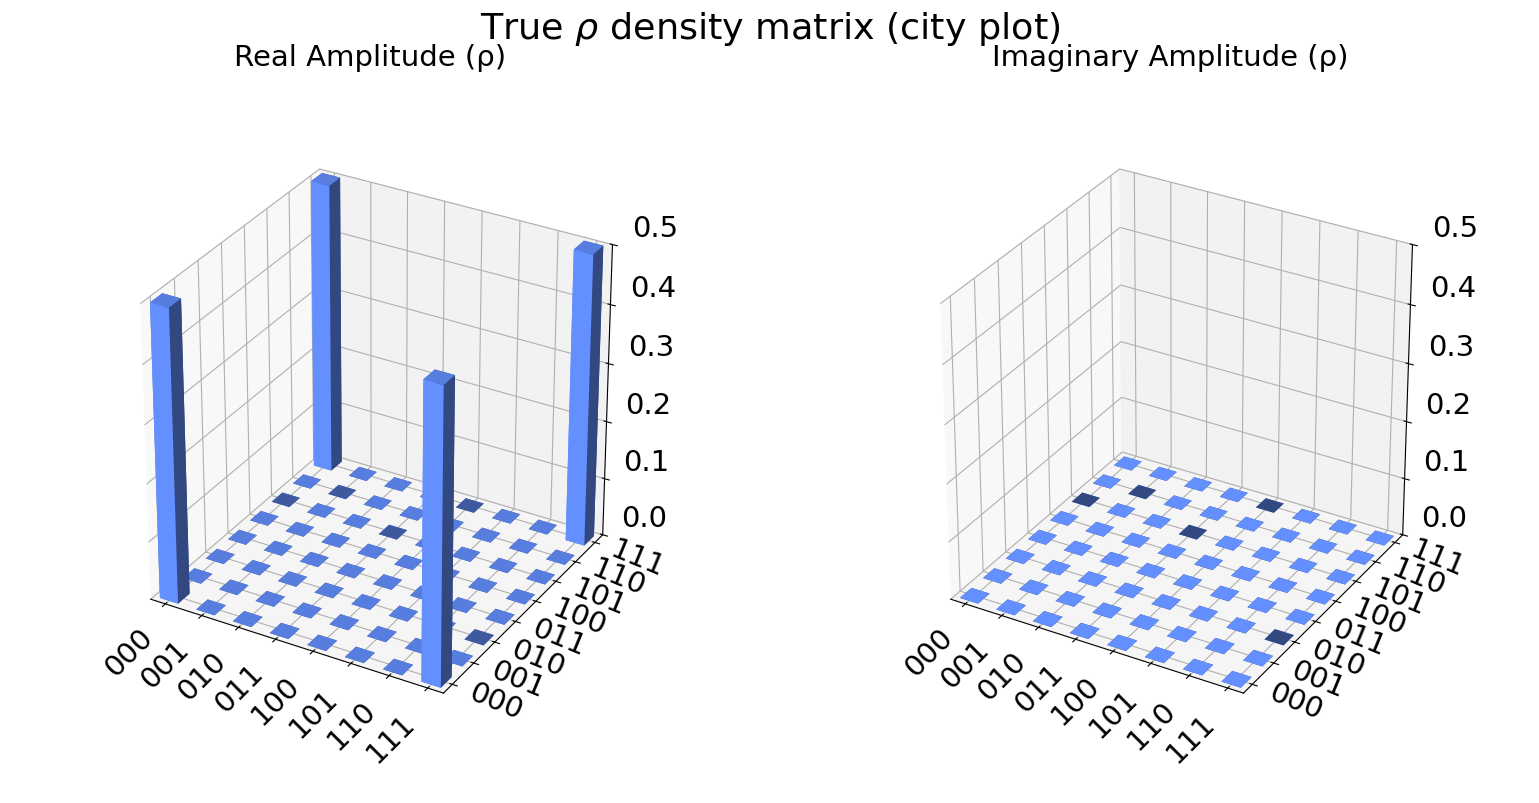

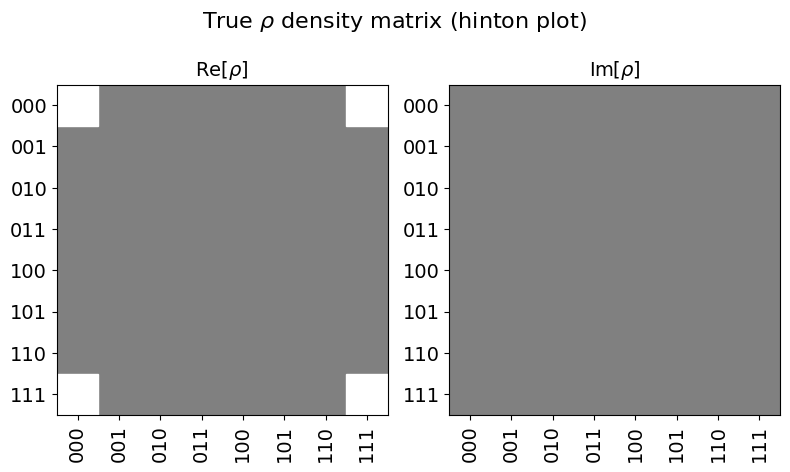

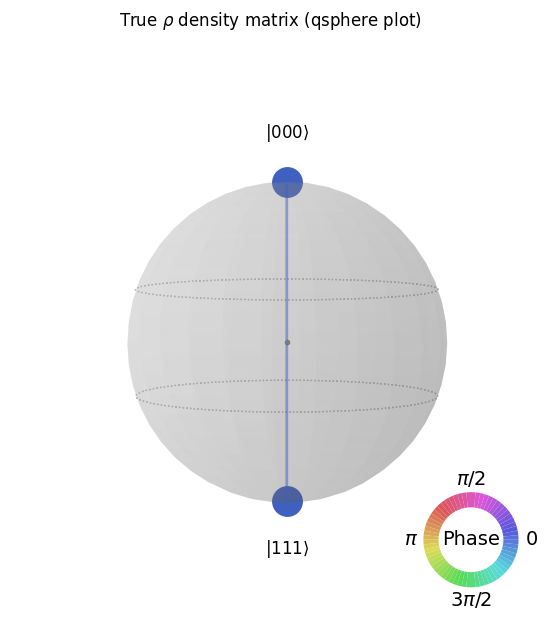

In [7]:
# true state circuit and density matrix
N = 3   # number of qubits
qc = create_ghz_state(N)
print('quantum circuit of the GHZ3 state:')
display(qc.draw())
rho_true = DensityMatrix(qc)

print('Density matrix of GHZ3 state:\n')
print(rho_true.data)

# -- print and plots provided by qiskit lib --
print('\nNice plots to draw the density matrix provided by qiskit:')

fig = plot_state_city(rho_true, title="True $\\rho$ density matrix (city plot)")
display(fig)
fig = plot_state_hinton(rho_true, title="True $\\rho$ density matrix (hinton plot)")
display(fig)
fig = plot_state_qsphere(rho_true)
fig.suptitle("True $\\rho$ density matrix (qsphere plot)")
display(fig)

**POVM Outcomes and Local SIC-POVMs**

In quantum information, a Generalised Measurement is mathematically described by a **Positive Operator-Valued Measure (POVM)**. A POVM is a set of positive semi-definite operators $\{M_a\}$ acting on the state space, where each index $a$ corresponds to a specific experimental **outcome**. These operators must satisfy the completeness relation:
$$\sum_{a} M_a = \mathbb{I}$$

***Single-Qubit system***

For a single qubit, we employ a **Symmetric Informationally Complete POVM (SIC-POVM)**, which consists of 4 projectors $\{M_{\alpha}\}_{\alpha=1}^4$ directed towards the vertices of a regular tetrahedron inside the Bloch sphere. 

SIC-POVMs are usefull for Quantum State Tomography because:
- **Information Completeness:** They span the entire operator space, allowing for the unique reconstruction of any arbitrary density matrix $\rho$.
- **Minimality:** They yield exactly 4 outcomes and then provides the minimal necessary information (3 independent probabilities + the normalization constraint) to reconstruct a state without statistical redundancy --> $\sim$ 3 independent cordinates

***Multi-Qubit system***

For an $N$-qubit system, the global POVM is constructed by taking the tensor product of local SIC-POVMs chosen for each individual qubit. 

A global outcome is indexed by a vector $\vec{a} = (a_1, a_2, \dots, a_N)$, where each $a_i \in \{0, 1, 2, 3\}$ denotes the local outcome obtained on the $i$-th qubit. The corresponding global POVM element $M_{\vec{a}}$ is defined as:
$$M_{\vec{a}} = M_{a_1} \otimes M_{a_2} \otimes \dots \otimes M_{a_N} = \bigotimes_{i=1}^{N} M_{a_i}$$
$\rightarrow$ The total number of global experimental outcomes is $4^N$

**Born's Rule and Exact Probabilities**

To determine the exact theoretical probability $p_{\vec{a}}$ of obtaining a specific multi-qubit outcome $\vec{a}$ from a given target state $\rho_{\text{true}}$, we evaluate **Born's Rule**:
$$p_{\vec{a}} = \text{Tr}(\rho_{\text{true}} M_{\vec{a}})$$

Once $\vec{p}_{\text{exact}}$ is determined, we simulate a finite-shot experiment by drawing $N_{\text{samples}}$ independent random outcomes distributed according to these exact probabilities.

In [10]:
# create data sampling the true probability distribution
n_samples = 500
p_exact = povm_probability(rho_true.data, N) # extract the true probability by Born's Rule
samples = sample_povm(p_exact, n_samples)    # sample the exact distribution

## Direct reconstruction: Inverse Born Rule

Let's first try to reconstruct the matrix directly from the inverse Born rule, using the empirical POVM distributions instead of the exact ones.

$$p_{a} = \text{Tr}(\rho M_{a})  \rightarrow  \rho = \sum_{a, a'} p_a (T^{-1})_{a, a'} M_{a'}$$

where $a, a' = (a_1, a_2, \dots, a_N)$ represent the global outcomes, and $T$ is the **overlap matrix** defined as:
$$T_{a, a'} = \text{Tr}[M_a M_{a'}]$$

In [11]:
# reconstruct density matrix direct from p_sample

# empirical distribution of samples
p_sample = samples_to_empirical_dist(samples, N)

# helpers
povm_dict = build_povm(N)   # returns all M(a) for every outcomes
P_vec    = pvec_from_pdict(p_sample, N)
T, T_inv = get_overlap_matrix(N)

# perform inverse Born's rule
rho_sample = reconstruct_rho(P_vec, N, T_inv, povm_dict)

# verify reconstructed rho
validate_rho(rho_sample);

  Hermitian:          True
  Tr(rho):            1.00000000
  Pos semi-definite:  False  (min eigval = -3.69e-01)


Direct reconstruction results in a matrix that is often mathematically **incorrect** as a quantum state and completely **unphysical**: valid quantum states cannot have negative eigenvalues (which would imply negative probabilities for certain measurement outcomes).
This motivates the need for constrained optimization techniques to strictly enforce:
1. $\rho = \rho^\dagger$ (Hermiticity)
2. $\text{Tr}(\rho) = 1$ (Normalization)
3. $\rho \ge 0$ (Positive semi-definiteness)

## Maximum Likelihood Estimator (MLE)

MLE searches for the statistically optimal density matrix $\rho$ that maximizes the probability of observing the collected experimental samples.

To ensure the reconstruction of a valid quantum state (*Hermitian* $\rho = \rho^\dagger$ and *positive semi-definite* $\rho \ge 0$) MLE re-parameterizes the density matrix using the **Cholesky decomposition**:

$$\rho(t) = \frac{T(t) T^\dagger(t)}{\text{Tr}[T(t) T^\dagger(t)]}$$

Where:
* $T(t)$ is a lower-triangular matrix whose entries are parameterized by a real vector of parameters $\vec{t}$.
* The product $T(t)T^\dagger(t)$ is **positive semi-definite** and **Hermitian** by construction for any choice of $T$.
* Dividing by the trace guarantees the strict **normalization constraint** ($\text{Tr}[\rho] = 1$).
$$T = \begin{pmatrix} 
t_1 & 0 & 0 & \dots & 0 \\ 
t_2 + i t_3 & t_4 & 0 & \dots & 0 \\ 
t_5 + i t_6 & t_7 + i t_8 & t_9 & \dots & 0 \\ 
\vdots & \vdots & \vdots & \ddots & \vdots \\ 
\dots & \dots & \dots & \dots & t_{d^2} 
\end{pmatrix}$$

By substituting $\rho(t)$ into Born's rule, the optimizer works directly on the unconstrained real parameters $\vec{t}$. The algorithm minimizes the negative log-likelihood function to find the best fit:

$$\vec{t}_{\text{opt}} = \arg\min_{\vec{t}} \mathcal{L}(\vec{t} \,|\, \text{samples})$$

In [12]:
# compute density matrix using MLE

# Negative LogLikelihood
nll = make_nll(samples, N)


# creates cholesky params array to initialize minuit
dim = 2**N
init_rho = np.eye(dim, dtype=complex) / dim   # max mixed state
p0 = rho_to_params(init_rho, N)
print(f"Cholesky params to minimize: {count_params(N)}  (= (2^N)^2, where N=3 )")
print(f'--> t_array dim: {len(p0)}, number of matrix entries: {dim**2}')


# create Minuit obj
m = Minuit(nll, *p0)
# iminuit built-in to use custom likelihood cost func --> for error estimation m.minos
m.errordef = Minuit.LIKELIHOOD   # = 0.5    
m.print_level = 0

m.migrad()                  
if not m.valid:
    print('not valid!')
    # second try
    m.migrad()
else:
    print('minimization completed!')  
print(f"\nMinuit valid:  {m.valid}")

Cholesky params to minimize: 64  (= (2^N)^2, where N=3 )
--> t_array dim: 64, number of matrix entries: 64
minimization completed!

Minuit valid:  True


In [13]:
# reconstruct matrix after minimization:
rho_mle = params_to_rho(np.array(m.values), N)

validate_rho(rho_mle);

  Hermitian:          True
  Tr(rho):            1.00000000
  Pos semi-definite:  True  (min eigval = 6.38e-12)


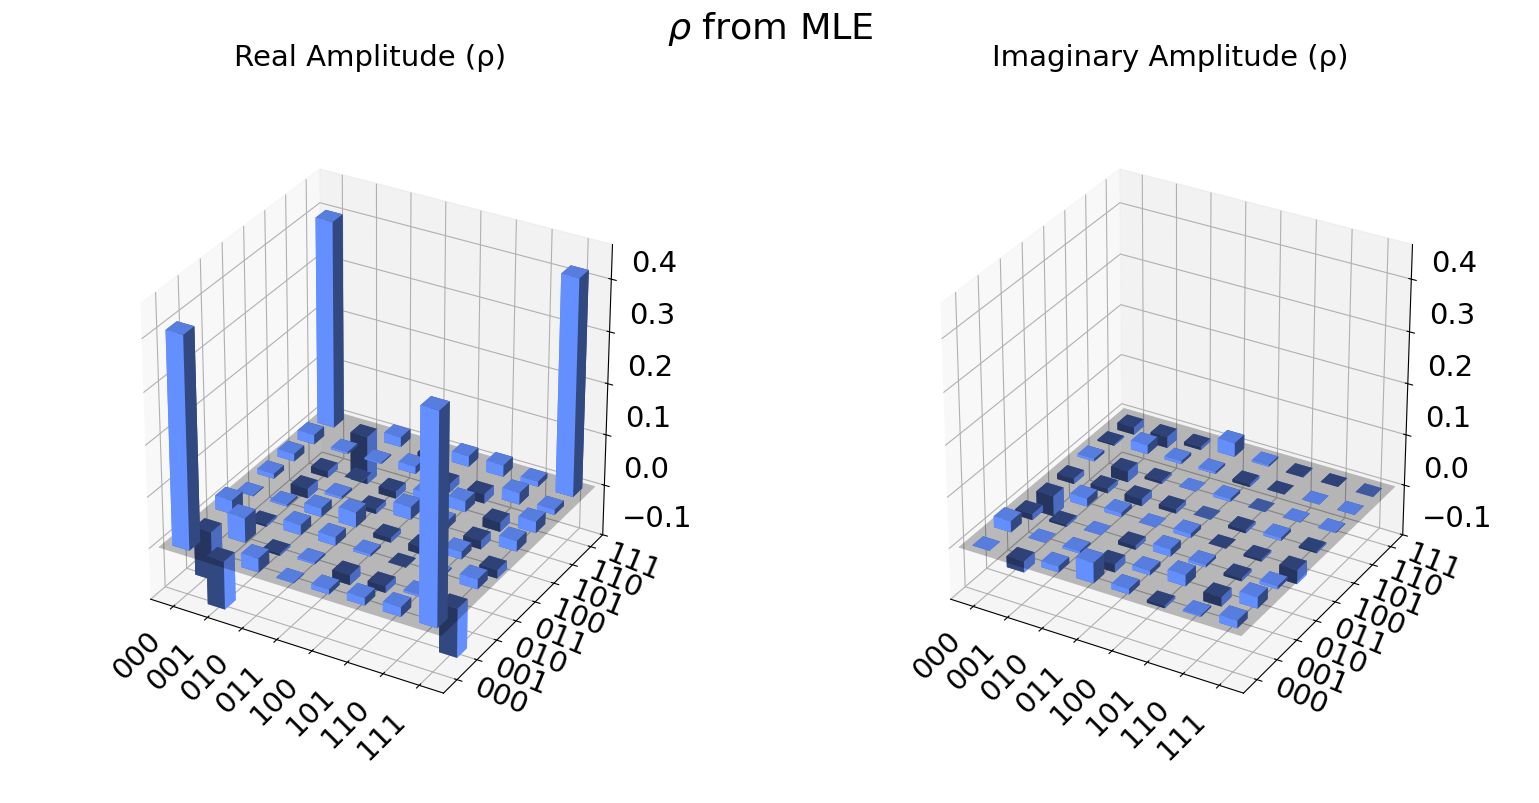

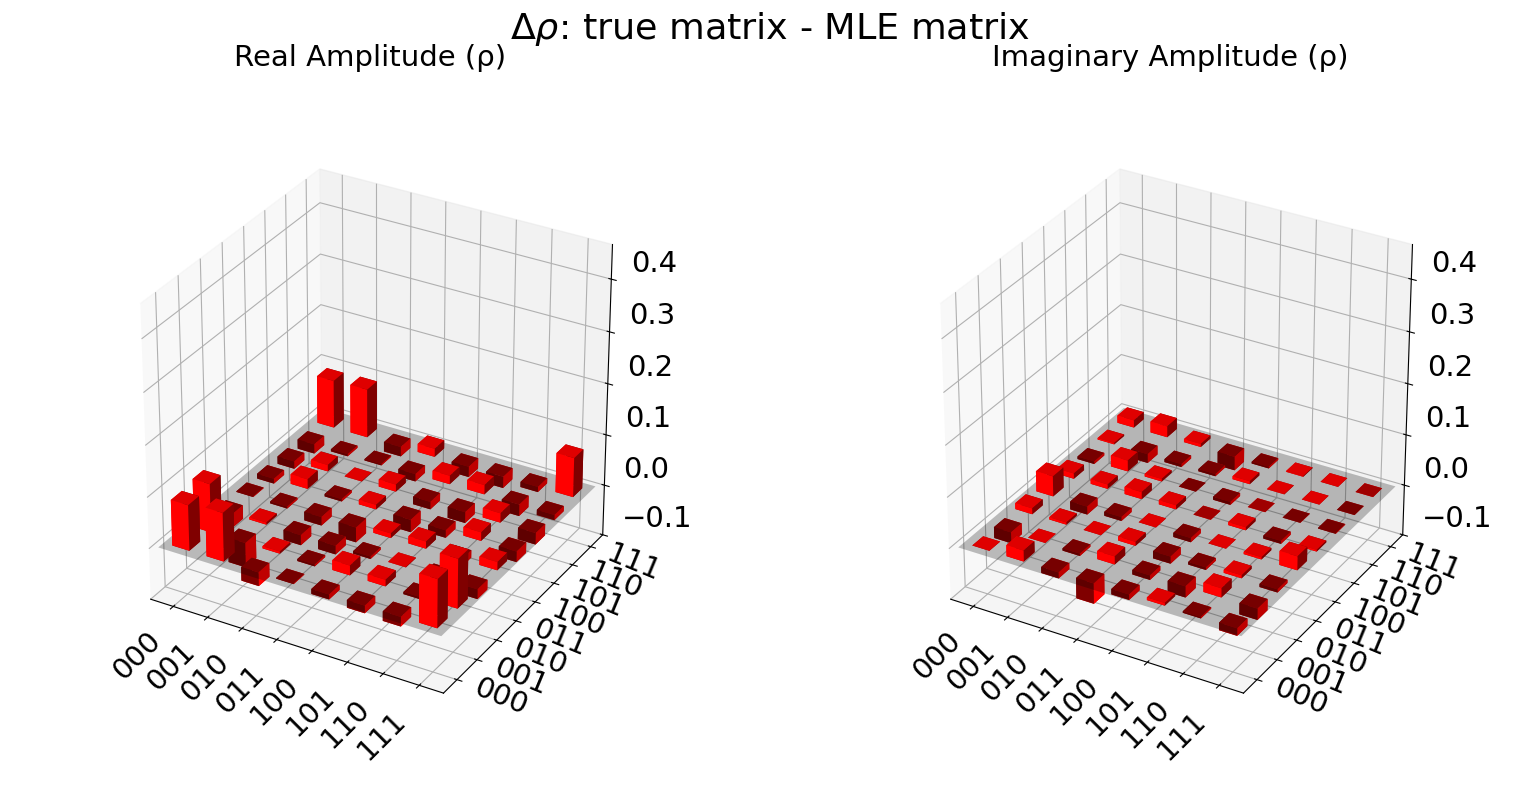

In [14]:
# -- plots --

# reconstructed matrix
fig_mle = plot_state_city(rho_mle, title='$\\rho$ from MLE')

# differences between the matrices
rho_diff = rho_true - rho_mle
fig_diff = plot_state_city(rho_diff, title="$\\Delta\\rho$: true matrix - MLE matrix", color=['red', 'red'])

# setting the same z-scale 
max_val = np.max(np.abs(rho_mle.data))
padding = max_val * 0.1
z_limit = max_val + padding  

for fig in [fig_mle, fig_diff]:
    for ax in fig.get_axes():
        ax.set_zlim(-0.1, z_limit)

display(fig_mle)
display(fig_diff)

### Fidelity

To benchmark our reconstruction models against the true state $\rho_{\text{true}}$, we evaluate **Quantum** and **Classical Fidelity**.

***Quantum Fidelity***

Quantum Fidelity quantifies the overlap between the true density matrix $\rho_{\text{true}}$ and the reconstructed density matrix $\rho_{\text{reconstructed}}$:

$$F_Q(\rho_{\text{true}}, \rho_{\text{reconstructed}}) = \left( \text{Tr} \sqrt{\sqrt{\rho_{\text{true}}} \rho_{\text{reconstructed}} \sqrt{\rho_{\text{true}}}} \right)^2$$

NB: you must reconstruct the whole matrix to evaluate $F_q$, not only the probability distribution of the outcomes.

***Classical Fidelity***

Classical Fidelity measures the similarity between two probability distributions. Given the theoretical POVM probability vector $\vec{p}$ and an empirical or estimated distribution $\vec{q}$ (Bhattacharyya coefficient):

$$F_C(\vec{p}, \vec{q}) = \left( \sum_{a} \sqrt{p_a q_a} \right)^2$$

NB: For the Maximum Likelihood Estimation, we apply Born's rule to the reconstructed state $\rho_{\text{mle}}$ to extract its exact predicted probabilities $\vec{p}_{\text{mle}}$. Then we then compute $F_C(\vec{p}_{\text{exact}}, \vec{p}_{\text{mle}})$, to establish a classical comparison baseline for VAE, which can not provides $F_q$.

NB: We also directly calculate the classical fidelity of the raw empirical data distribution (the noisy finite-shot samples) against $\vec{p}_{\text{exact}}$. This serves as a noisy baseline to precisely quantify the physical denoising performance and improvement provided by our models (VAE).

In [15]:
# quantum fidelity 
fq = quantum_fidelity(rho_true, rho_mle)
print(f"quantum fidelity F_q = {fq:.6f}")

# -- classical fidelity --
p_sample = samples_to_empirical_dist(samples, N)
fc    = classical_fidelity(p_exact, p_sample)
print(f"classical fidelity (exact vs sample)  F_c  = {fc:.6f}")

p_mle = povm_probability(rho_mle, N)    # extract predicted probs: they are "exact", no shot noise
fc    = classical_fidelity(p_exact, p_mle)
print(f"classical fidelity (exact vs mle)     F_c  = {fc:.6f}")

quantum fidelity F_q = 0.822625
classical fidelity (exact vs sample)  F_c  = 0.975142
classical fidelity (exact vs mle)     F_c  = 0.992438


## Variational AutoEncoder (VAE)

Here we use VAE to train a generative neural network to approximate the true underlying probability distribution by learning a compressed latent representation of the observed experimental samples.

Our models use a *One-Hot Encoding* scheme to represent the discrete POVM outcomes: each local outcome is mapped to a 4-dimensional binary vector and the individual qubit vectors are concatenated.

Given a 3-qubit measurement outcome $\vec{a} = (a_1, a_2, a_3)$, where each $a_i \in \{0, 1, 2, 3\}$, the encoding transformation proceeds as follows:
$$\vec{a} = \begin{pmatrix} 1 \\ 2 \\ 0 \end{pmatrix} \longrightarrow \vec{x}_{\text{one-hot}} = \Big[ \underbrace{0, 1, 0, 0}_{\text{Qubit 1 } (a_1=1)}, \,\, \underbrace{0, 0, 1, 0}_{\text{Qubit 2 } (a_2=2)}, \,\, \underbrace{1, 0, 0, 0}_{\text{Qubit 3 } (a_3=0)} \Big]$$

$\rightarrow $ The input representation goes from $N$ to a binary vector of size **$4N$**. 

In [16]:
# Convert the samples to one-hot encoding
onehot_samples = samples_to_onehot(samples, N)

In [17]:
# Split the data into training and testing sets (unsupervised: no labels, no stratify)
X_train, X_test = train_test_split(onehot_samples, test_size=0.2, random_state=42)

print(f"Training set size and shape: {len(X_train)} and {X_train.shape}")
print(f"Testing set size and shape: {len(X_test)} and {X_test.shape}")

Training set size and shape: 400 and (400, 12)
Testing set size and shape: 100 and (100, 12)


### VAE model building and fit

In [18]:
# Define config parameters for the VAE setup and training
LATENT_DIM = 16         # latent space dim
HIDDEN_DIM = 96         # number of neurons in the hidden layers (both encoder/decoder)
WARMUP_EPOCHS = 50      # epochs for KL weight annealing strategy
TOTAL_EPOCHS = 500
BATCH_SIZE = 100
LEARNING_RATE = 1e-3
BETA_MAX = 0.85         # max value for the KL weight

Most of the VAE parameters depend on the dimension of the system (*N_qubits*).
For N=3 we implement an architechture made of these layers:

[Input] $\rightarrow$ [Hidden : 96] $\rightarrow$ [Hidden : 96] $\rightarrow$ [Latent : (16, 2)] $\rightarrow$ [Hidden : 96] $\rightarrow$ [Hidden : 96] $\rightarrow$ [Output]

The model is trained to reconstruct the input state by encoding, sampling the latent space and decoding the latent values.
Once trained, this allows using the decoder as a synthetic generator of sample accoring to the learned state.

To train the network, we minimize the ELBO loss, which consists of two competing terms:
$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{reconstruction}} + \beta \cdot D_{\text{KL}}\big(q_\phi(z|x) \,||\, p(z)\big)$$

- $\mathcal{L}_{\text{reconstruction}}$ : since our POVM outcomes are categorical variables represented via One-Hot encoding, we implement the Categorical Cross-Entropy between the original input samples and the reconstructed probabilities generated by the decoder. This forces the model to accurately preserve the physical measurement distributions.
- $D_{\text{KL}}$ : the Kullback-Leibler (KL) divergence measures how much the predicted latent distribution $q_\phi(z|x)$ deviates from a standard Gaussian prior $p(z) \sim \mathcal{N}(0, I)$. The hyperparameter $\beta$ acts as a scaling weight to balance the two terms.


In [20]:
# create and compile the VAE model
vae = VAE(n_qubits=N, latent_dim=LATENT_DIM, hidden=HIDDEN_DIM)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))
vae.build(input_shape=(None, 4*N))

We use a *KLWarmup* Custom Callback to implement a *annealing schedule* (or warmup) for the $\beta$ weight of the KL divergence term: it gradually linearly increases to its final target value over a set number of epochs. 

NB: By dynamically increasing $\beta$, we allow the model to first focus entirely on learning how to encode and decode the basic features of the quantum state (maximizing reconstruction accuracy). Once a coherent representation is established, the gradual activation of the KL penalty smoothly regularizes the latent space into a continuous Gaussian structure without destroying the learned features.


In [21]:
# fit:

# Define callbacks for training
callbacks = [
    KLWarmup(beta_max=BETA_MAX, warmup_epochs=WARMUP_EPOCHS),
    EarlyStopping(monitor='loss', mode='min',
                  patience=50, restore_best_weights=True, 
                  start_from_epoch=WARMUP_EPOCHS),
    ReduceLROnPlateau(monitor='loss', mode='min',          # keras callback to reduce LR in the final steps of training
                      factor=0.5, patience=20, min_lr=1e-6),
]

# fit data
history = vae.fit(
    X_train, X_train,
    epochs=TOTAL_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, X_test),
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - kl_loss: 0.2544 - kl_weight: 0.0170 - loss: 4.2286 - reconstruction_loss: 4.2243 - val_kl_loss: 0.2750 - val_loss: 4.1918 - val_reconstruction_loss: 4.1871 - learning_rate: 0.0010
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - kl_loss: 0.3128 - kl_weight: 0.0340 - loss: 4.1049 - reconstruction_loss: 4.0943 - val_kl_loss: 0.3259 - val_loss: 4.1790 - val_reconstruction_loss: 4.1679 - learning_rate: 0.0010
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - kl_loss: 0.3970 - kl_weight: 0.0510 - loss: 4.0821 - reconstruction_loss: 4.0619 - val_kl_loss: 0.4142 - val_loss: 4.1376 - val_reconstruction_loss: 4.1165 - learning_rate: 0.0010
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - kl_loss: 0.5154 - kl_weight: 0.0680 - loss: 4.0632 - reconstruction_loss: 4.0282 - val_kl_loss: 0.5364 - val_loss: 4.0126 - val_reconstruction_loss: 3.9761 - learning_rate: 0.0010
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - kl_loss: 0.6320 - kl

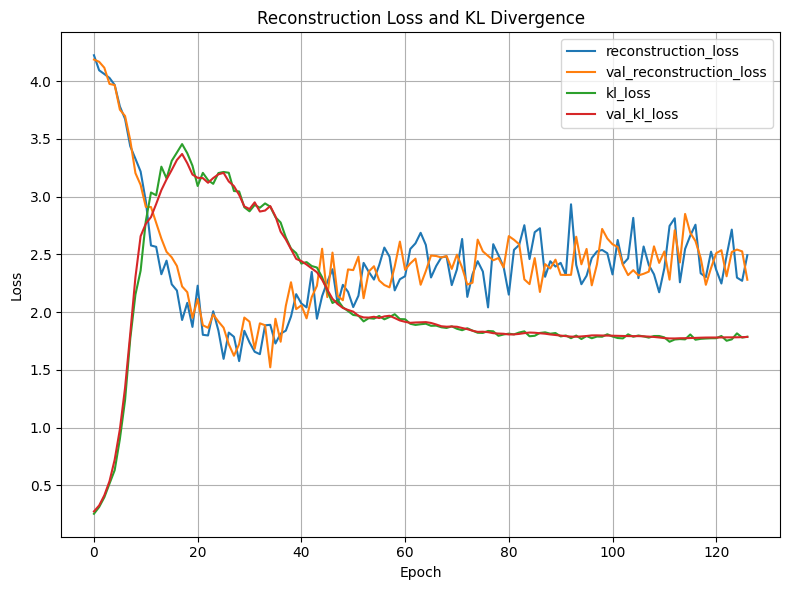

In [22]:
# plot the training and validation loss curves
plot_reconstruction_and_kl_divergence(history)
# plot_total_loss(history)

The plot displays the training history of the VAE, highlighting the dynamic interaction between the reconstruction error and the KL divergence governed by the **KL Warmup** mechanism.

- The **Reconstruction Loss** drops sharply because the regularization weight $\beta$ starts near zero, letting the network focus entirely on matching the input data. Concurrently, the **KL Loss** grows rapidly as the encoder shapes the latent space without constraints or regularizations.
- As the warmup schedule increases $\beta$, the KL penalty becomes dominant. The optimizer is forced to compress the latent space back toward a standard Gaussian prior, causing the **KL Loss** to decrease and stabilize. As a natural trade-off, the **Reconstruction Loss** sightly increases.
- All curves reach a stable plateau. 

### Fidelity

Once trained, we use the VAE to generate a large number of samples to estimate the distribution it has learned ($p_{\text{VAE}}$). Specifically, we sample a total number of points $N_{\text{synthetic}} \gg N_{\text{samples}}$ so that the empirical shot noise of the generated VAE distribution becomes negligible.

As we said, we also compare the Fidelities of:
- *Uniform distribution*: $\rightarrow$ baseline reference score, representing a completely uninformative guess
- *Empirical samples of training* $\rightarrow$ directly from the training data distribution $p_{\text{empirical}}$, to evaluate the potential denoising performance of the generative model compared to the raw, noisy experimental data

In [23]:
# classical fidelity analysis and comparison

outcomes = list(p_exact.keys())

# Generate a large number of samples from the trained VAE model to estimate the distribution it has learned (p_vae)
# Convert the one-hot encoded training data back to samples and compute the empirical distribution (p_train)
p_vae   = vae.predict_dist(n_samples=1000000, batch_size=50_000)
p_unif = {o: 1.0 / len(outcomes) for o in outcomes}
p_train = samples_to_empirical_dist(onehot_to_samples(X_train, N), N)   # N_train are less then total N_samples

# Compute the classical fidelity between the distributions
classical_fidelity_floor = classical_fidelity(p_unif, p_exact)
classical_fidelity_vae = classical_fidelity(p_vae, p_exact)
classical_fidelity_train = classical_fidelity(p_train, p_exact)

print("=== Classical Fidelity ===")
print(f"  uniform          vs true : {classical_fidelity_floor:.4f}   <- FLOOR")
print(f"  VAE              vs true : {classical_fidelity_vae:.4f}   <- MODEL")
print(f"  training data    vs true : {classical_fidelity_train:.4f}   <- BASELINE\n")

=== Classical Fidelity ===
  uniform          vs true : 0.9510   <- FLOOR
  VAE              vs true : 0.9755   <- MODEL
  training data    vs true : 0.9741   <- BASELINE

